# 🏥 Medical Equipment Suppliers — Simplified Analysis

**Stack:** `pandas` · `numpy` · `matplotlib` · `scikit-learn` only

| # | Question |
|---|---|
| **Q1** | What are the most important features and how do they drive the outcome? |
| **Q2** | What unusual or creative insights can be gathered? |
| **Q3** | How accurate is the trained model? |
| **Q4** | What happens in a creative predictive scenario? |

---

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# scikit-learn — everything we need
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.inspection import permutation_importance

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#1976D2', '#E53935', '#43A047', '#8E24AA', '#FB8C00']

print("imports OK")


Matplotlib is building the font cache; this may take a moment.


imports OK


## 1. Load Data & Feature Engineering

In [5]:
# Load dataset
df = pd.read_csv('Medical-Equipment-Suppliers.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


Shape: 58,191 rows × 17 columns


,provider_id,acceptsassignement,participationbegindate,businessname,practicename,practiceaddress1,practiceaddress2,practicecity,practicestate,practicezip9code,telephonenumber,specialitieslist,providertypelist,supplieslist,latitude,longitude,is_contracted_for_cba
0,34362104,True,2025-11-12,CLEAR VIEW OPTIX LLC,CLEAR VIEW OPTIX LLC,8481 SE 165TH MULBERRY LN,NaN,THE VILLAGES,FL,321625847,3522596789,Optician,NaN,Prosthetic Lenses: Conventional Eyeglasses|Pro...,28.981584,-82.011855,False
1,34362542,True,2025-11-12,PEARLAND DME SUPPLY LLC,PEARLAND DME SUPPLY LLC,2010 BROADWAY ST,STE 134,PEARLAND,TX,775815953,3467807723,Medical Supply Company Other,NaN,"Commodes, Urinals, Bedpans|Blood Glucose Monit...",29.548323,-95.245848,False
2,34362506,True,2025-11-10,CURE CRAFTER RX 2 INC.,CURE CRAFTER RX 2 INC.,17824 JAMAICA AVE,NaN,JAMAICA,NY,114325616,7185230195,Pharmacy,NaN,Epoetin|Immunosuppressive Drugs|Infusion Drugs...,40.707932,-73.782356,False


In [6]:
# ── Date → tenure in years ────────────────────────────────────────────────────
df['participationbegindate'] = pd.to_datetime(df['participationbegindate'], errors='coerce')
df['tenure_years'] = (
    (pd.Timestamp('2024-01-01') - df['participationbegindate']).dt.days / 365.25
).round(2)

# ── Pipe-delimited list → count of items ─────────────────────────────────────
for col, new_col in [('supplieslist',    'supplies_count'),
                      ('specialitieslist','speciality_count'),
                      ('providertypelist','providertype_count')]:
    df[new_col] = df[col].fillna('').apply(lambda x: len(x.split('|')) if x else 0)

# ── Binary flags from free-text columns ──────────────────────────────────────
flags = {
    'is_pharmacy' : ('specialitieslist', 'Pharmacy'),
    'is_optician' : ('specialitieslist', 'Optician'),
    'is_ortho'    : ('specialitieslist', 'Orthotic|Prosthetic'),
    'is_oxygen'   : ('providertypelist', 'OXYGEN'),
    'is_grocery'  : ('specialitieslist', 'Grocery'),
}
for flag, (src_col, pattern) in flags.items():
    df[flag] = df[src_col].fillna('').str.contains(pattern, case=False, regex=True).astype(int)

# ── Encode state ──────────────────────────────────────────────────────────────
df['state_encoded'] = LabelEncoder().fit_transform(df['practicestate'].fillna('XX'))

# ── Pre-compute state stats (before any subsetting) ───────────────────────────
state_stats = (
    df.groupby('practicestate')
      .agg(total=('provider_id', 'count'), accept_rate=('acceptsassignement', 'mean'))
      .query('total >= 100')
      .sort_values('accept_rate')
      .copy()
)

print("✓ Feature engineering done.")
print(f"   Engineered columns: tenure_years, supplies_count, speciality_count,")
print(f"   providertype_count, is_pharmacy, is_optician, is_ortho, is_oxygen,")
print(f"   is_grocery, state_encoded")


✓ Feature engineering done.
   Engineered columns: tenure_years, supplies_count, speciality_count,
   providertype_count, is_pharmacy, is_optician, is_ortho, is_oxygen,
   is_grocery, state_encoded


In [7]:
# ── Missing value summary ─────────────────────────────────────────────────────
missing = df.isnull().sum()
print(missing[missing > 0].to_string())


practiceaddress2    45038
specialitieslist      777
providertypelist    51323
supplieslist           32


---
## ❶ Q1 — Feature Importance

**Target:** `acceptsassignement` — supplier accepts Medicare's approved payment as full payment.

| Feature | What it measures | How it drives acceptance |
|---|---|---|
| `supplies_count` | Distinct product types offered | More products → stronger Medicare dependency |
| `tenure_years` | Years since enrolment | Non-linear — newest & oldest least compliant |
| `is_pharmacy` | Pharmacy flag | Pharmacies rely on guaranteed Medicare revenue |
| `latitude/longitude` | Geographic location | Urban density & competition shape decisions |
| `state_encoded` | US state | State Medicaid policy varies widely |
| `speciality_count` | Number of specialities | Multi-speciality → broader Medicare base |
| `is_oxygen` | Oxygen equipment flag | Highly regulated; assignment near-mandatory |
| `is_ortho` | Orthotics/Prosthetics flag | Often under CMS-mandated reimbursement |
| `is_optician` | Optician flag | Can bill directly; lower Medicare dependency |
| `is_grocery` | Grocery store flag | In-store pharmacies; volume-driven |
| `providertype_count` | Provider type diversity | Larger, more integrated organisations |


In [8]:
# ── Prepare features & target ─────────────────────────────────────────────────
FEATURES = [
    'tenure_years', 'supplies_count', 'speciality_count', 'providertype_count',
    'is_pharmacy', 'is_optician', 'is_ortho', 'is_oxygen', 'is_grocery',
    'state_encoded', 'latitude', 'longitude'
]
TARGET = 'acceptsassignement'

dm = df[FEATURES + [TARGET]].dropna()
X  = dm[FEATURES].copy()
y  = dm[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Class balance — 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")


Train: 46,552  |  Test: 11,639
Class balance — 0: 28,173  |  1: 30,018


/opt/anaconda3/envs/analysis/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/analysis/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/analysis/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/analysis/lib/python3.11/site-packag

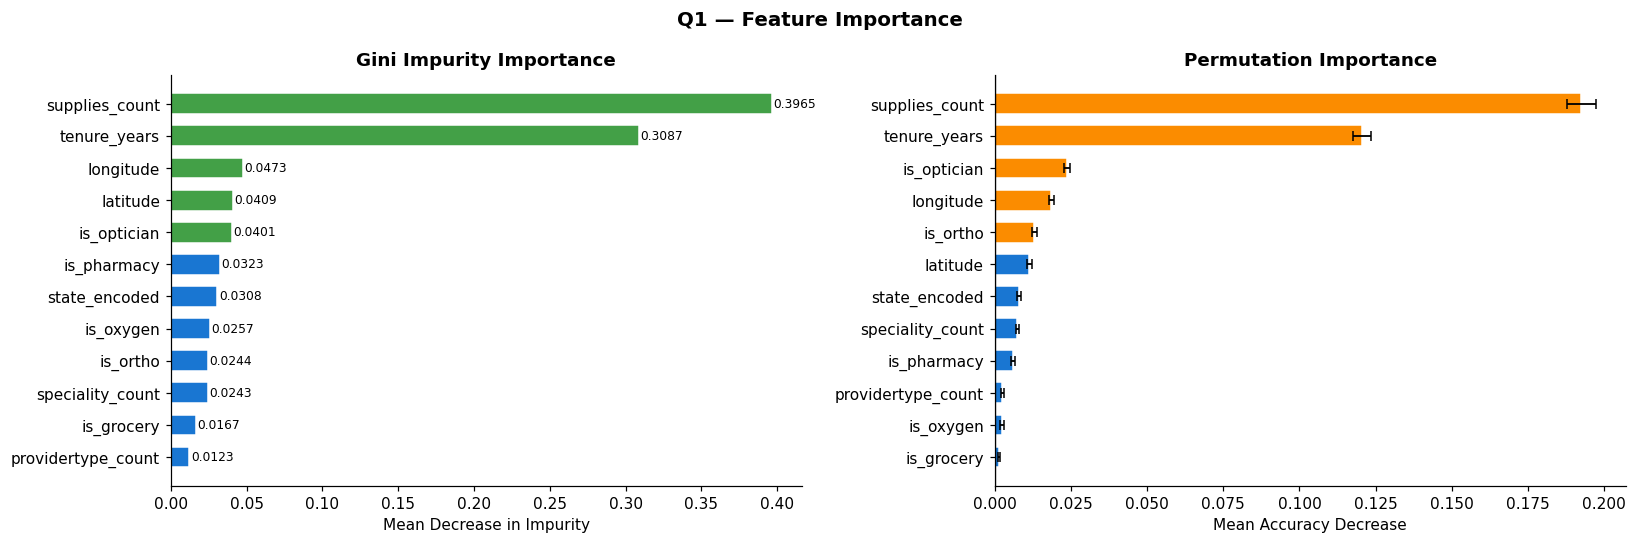

In [9]:
# ── Train Random Forest ───────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ── Gini importance ───────────────────────────────────────────────────────────
gini = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

# ── Permutation importance ────────────────────────────────────────────────────
perm = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cg = [PALETTE[0] if v < gini.quantile(0.6) else PALETTE[2] for v in gini.values]
b0 = axes[0].barh(gini.index, gini.values, color=cg, edgecolor='white', height=0.65)
axes[0].set_title('Gini Impurity Importance', fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity')
for b, v in zip(b0, gini.values):
    axes[0].text(v + 0.001, b.get_y() + b.get_height()/2, f'{v:.4f}', va='center', fontsize=8)

cp = [PALETTE[0] if v < perm_imp.quantile(0.6) else PALETTE[4] for v in perm_imp.values]
axes[1].barh(perm_imp.index, perm_imp.values, color=cp, edgecolor='white', height=0.65,
             xerr=perm.importances_std[np.argsort(perm.importances_mean)],
             capsize=3, error_kw={'elinewidth': 1.2})
axes[1].set_title('Permutation Importance', fontweight='bold')
axes[1].set_xlabel('Mean Accuracy Decrease')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Q1 — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


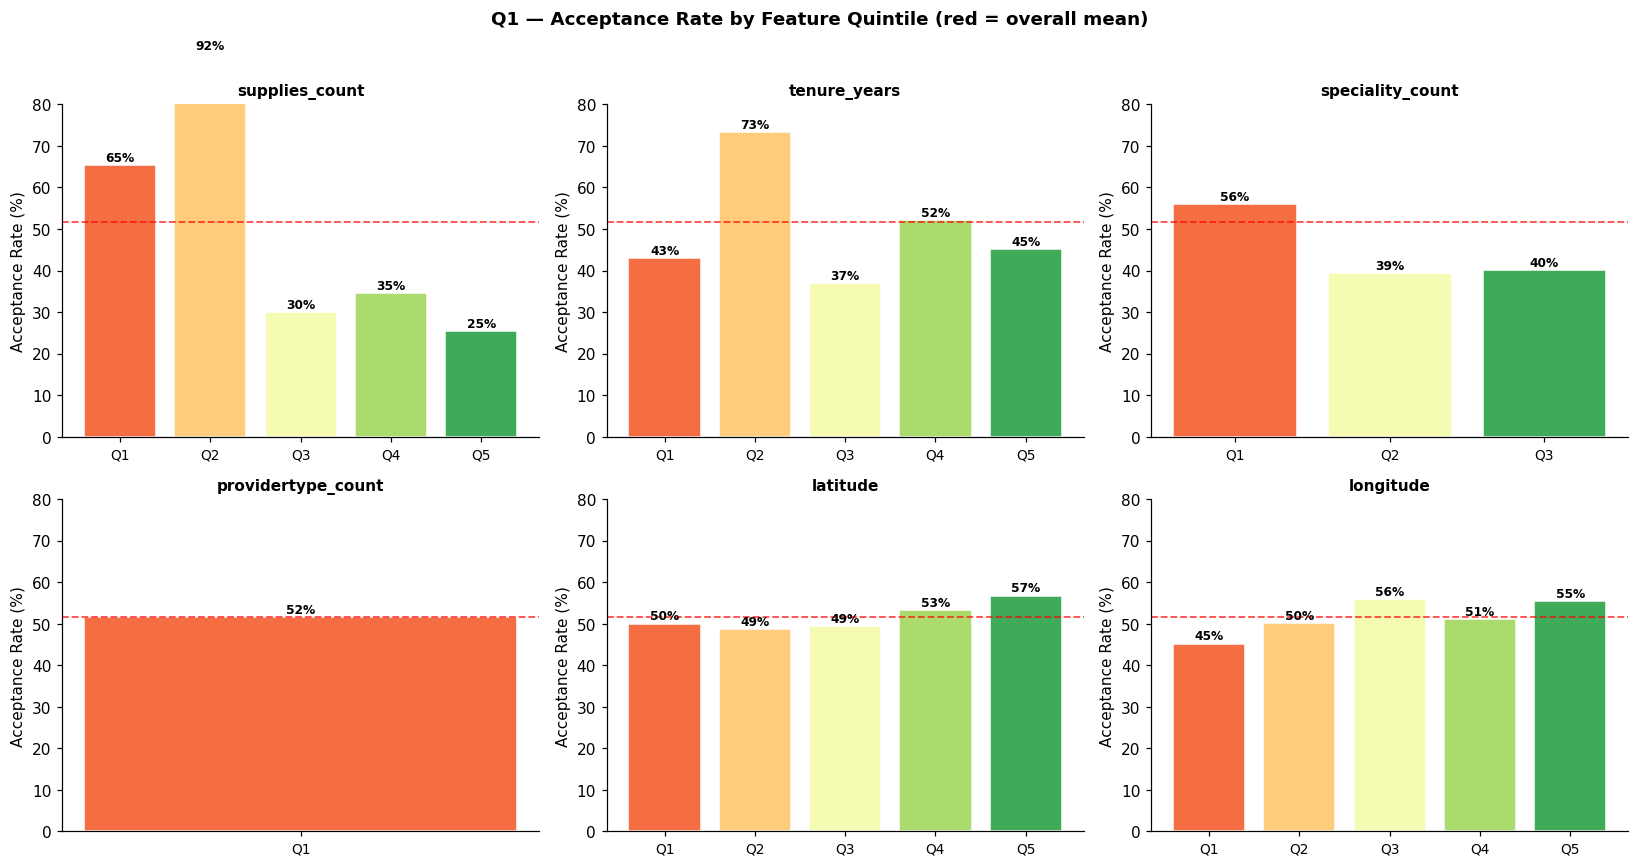

In [10]:
# ── Acceptance rate by quintile — shows direction of each feature's effect ─────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, ['supplies_count', 'tenure_years', 'speciality_count',
                             'providertype_count', 'latitude', 'longitude']):
    bins = pd.qcut(df[feat].dropna(), q=5, duplicates='drop')
    rate = df.groupby(bins, observed=True)[TARGET].mean()
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(rate)))
    bars = ax.bar(range(len(rate)), rate.values * 100, color=colors, edgecolor='white')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(rate))], fontsize=9)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_ylabel('Acceptance Rate (%)')
    ax.set_ylim(0, 80)
    ax.axhline(y.mean() * 100, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Overall mean')
    for b, v in zip(bars, rate.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{v:.0%}',
                ha='center', fontsize=8, fontweight='bold')

fig.suptitle('Q1 — Acceptance Rate by Feature Quintile (red = overall mean)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


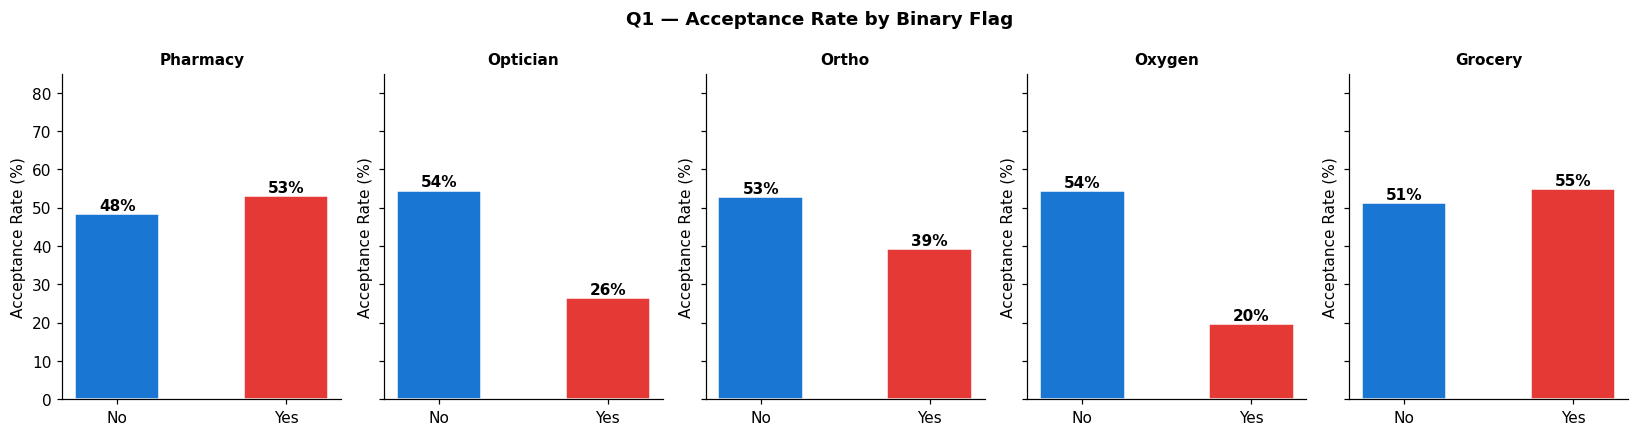

In [11]:
# ── Binary flag comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=True)

for ax, flag in zip(axes, ['is_pharmacy', 'is_optician', 'is_ortho', 'is_oxygen', 'is_grocery']):
    rates = df.groupby(flag)[TARGET].mean() * 100
    ax.bar(['No', 'Yes'], [rates.get(0, 0), rates.get(1, 0)],
           color=[PALETTE[0], PALETTE[1]], edgecolor='white', width=0.5)
    ax.set_title(flag.replace('is_', '').capitalize(), fontweight='bold', fontsize=10)
    ax.set_ylabel('Acceptance Rate (%)')
    ax.set_ylim(0, 85)
    for i, v in enumerate([rates.get(0, 0), rates.get(1, 0)]):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Q1 — Acceptance Rate by Binary Flag', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


---
## ❷ Q2 — Creative & Unusual Insights

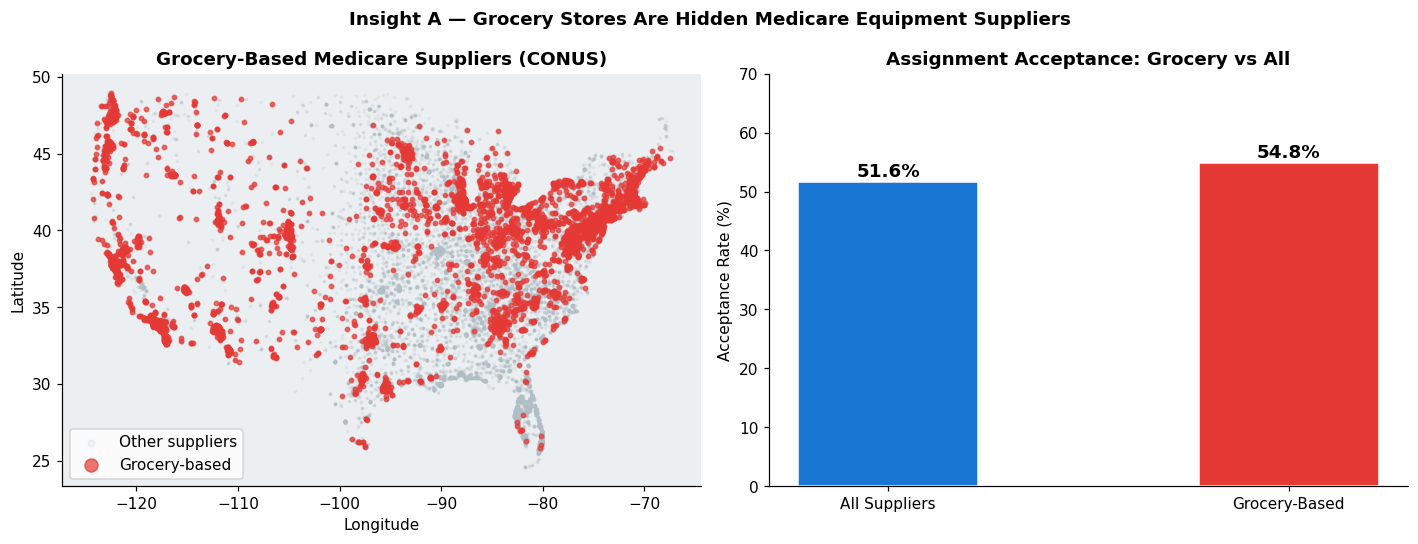

  5,136 grocery-based suppliers (8.8% of total)
  Acceptance rate: 54.8%  vs  overall 51.6%


In [12]:
# ── Insight A: Grocery stores as stealth Medicare suppliers ───────────────────
gr  = df[df['is_grocery'] == 1]
ngr = df[df['is_grocery'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sub  = gr[gr['latitude'].between(24, 50)  & gr['longitude'].between(-125, -65)]
nsub = ngr[ngr['latitude'].between(24, 50) & ngr['longitude'].between(-125, -65)]

axes[0].scatter(nsub['longitude'], nsub['latitude'], s=2, alpha=0.15, color='#B0BEC5',
                rasterized=True, label='Other suppliers')
axes[0].scatter(sub['longitude'],  sub['latitude'],  s=8, alpha=0.7,  color=PALETTE[1],
                rasterized=True, label='Grocery-based')
axes[0].set_facecolor('#ECEFF1')
axes[0].set_title('Grocery-Based Medicare Suppliers (CONUS)', fontweight='bold')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=3)

rv   = [df[TARGET].mean(), gr[TARGET].mean()]
bars = axes[1].bar(['All Suppliers', 'Grocery-Based'], [v * 100 for v in rv],
                   color=[PALETTE[0], PALETTE[1]], width=0.45, edgecolor='white')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_title('Assignment Acceptance: Grocery vs All', fontweight='bold')
axes[1].set_ylim(0, 70)
for b, v in zip(bars, rv):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Insight A — Grocery Stores Are Hidden Medicare Equipment Suppliers',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"  {len(gr):,} grocery-based suppliers ({len(gr)/len(df)*100:.1f}% of total)")
print(f"  Acceptance rate: {gr[TARGET].mean():.1%}  vs  overall {df[TARGET].mean():.1%}")


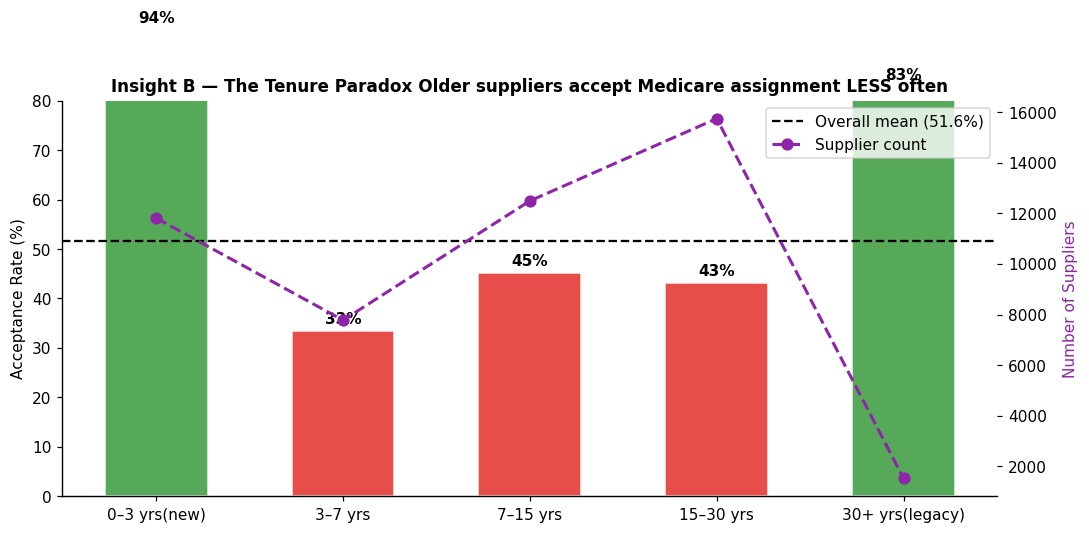

In [17]:
# ── Insight B: Tenure paradox — older suppliers accept LESS ──────────────────
vld = df[df['tenure_years'].between(0, 80)].copy()
tb  = pd.cut(vld['tenure_years'], bins=[0, 3, 7, 15, 30, 80],
             labels=['0–3 yrs(new)', '3–7 yrs', '7–15 yrs', '15–30 yrs', '30+ yrs(legacy)'])
ta  = vld.groupby(tb, observed=True)[TARGET].mean()
tc  = vld.groupby(tb, observed=True).size()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bc   = [PALETTE[2] if v >= ta.mean() else PALETTE[1] for v in ta.values]
bars = ax1.bar(ta.index.astype(str), ta.values * 100, color=bc, edgecolor='white', width=0.55, alpha=0.9)
ax1.axhline(df[TARGET].mean() * 100, color='black', linestyle='--', linewidth=1.5,
            label=f'Overall mean ({df[TARGET].mean():.1%})')
ax1.set_ylabel('Acceptance Rate (%)'); ax1.set_ylim(0, 80)
ax1.set_title('Insight B — The Tenure Paradox Older suppliers accept Medicare assignment LESS often', fontweight='bold', fontsize=11)
ax2.plot(tc.index.astype(str), tc.values, 'o--', color=PALETTE[3], linewidth=2, markersize=7, label='Supplier count')
ax2.set_ylabel('Number of Suppliers', color=PALETTE[3])
for b, v in zip(bars, ta.values):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
             f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='upper right')
plt.tight_layout(); plt.show()


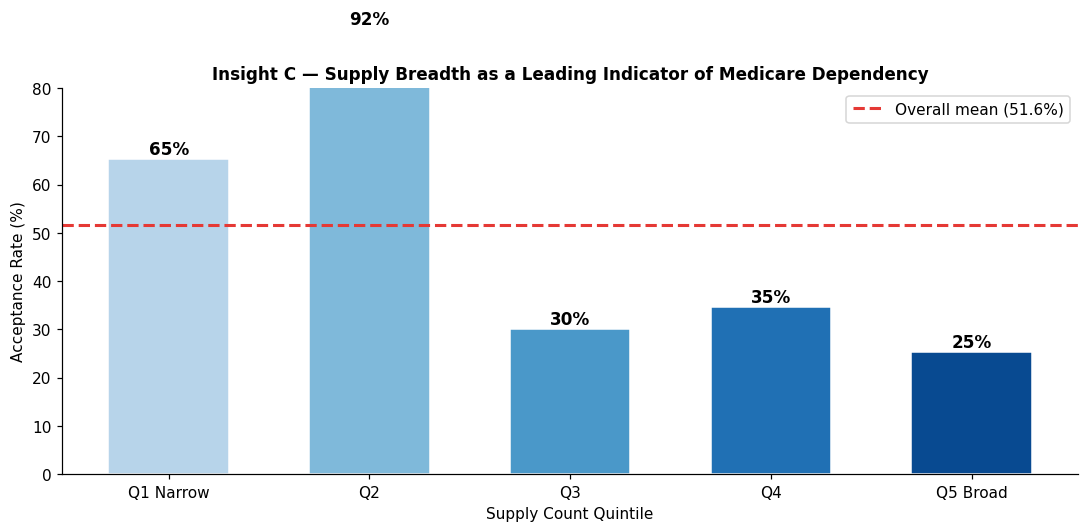

  Q1 → Q5 acceptance rate lift: +-39.9 percentage points


In [19]:
# ── Insight C: Supply breadth drives acceptance ───────────────────────────────
sq = pd.qcut(df['supplies_count'], q=5,
             labels=['Q1 Narrow', 'Q2', 'Q3', 'Q4', 'Q5 Broad'])
sa = df.groupby(sq, observed=True)[TARGET].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(sa.index.astype(str), sa.values * 100,
              color=plt.cm.Blues(np.linspace(0.3, 0.9, len(sa))), edgecolor='white', width=0.6)
ax.axhline(df[TARGET].mean() * 100, color=PALETTE[1], linestyle='--', linewidth=2,
           label=f'Overall mean ({df[TARGET].mean():.1%})')
ax.set_title('Insight C — Supply Breadth as a Leading Indicator of Medicare Dependency',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Supply Count Quintile'); ax.set_ylabel('Acceptance Rate (%)'); ax.set_ylim(0, 80)
ax.legend()
for b, v in zip(bars, sa.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{v:.0%}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

delta = (sa.iloc[-1] - sa.iloc[0]) * 100
print(f"  Q1 → Q5 acceptance rate lift: +{delta:.1f} percentage points")


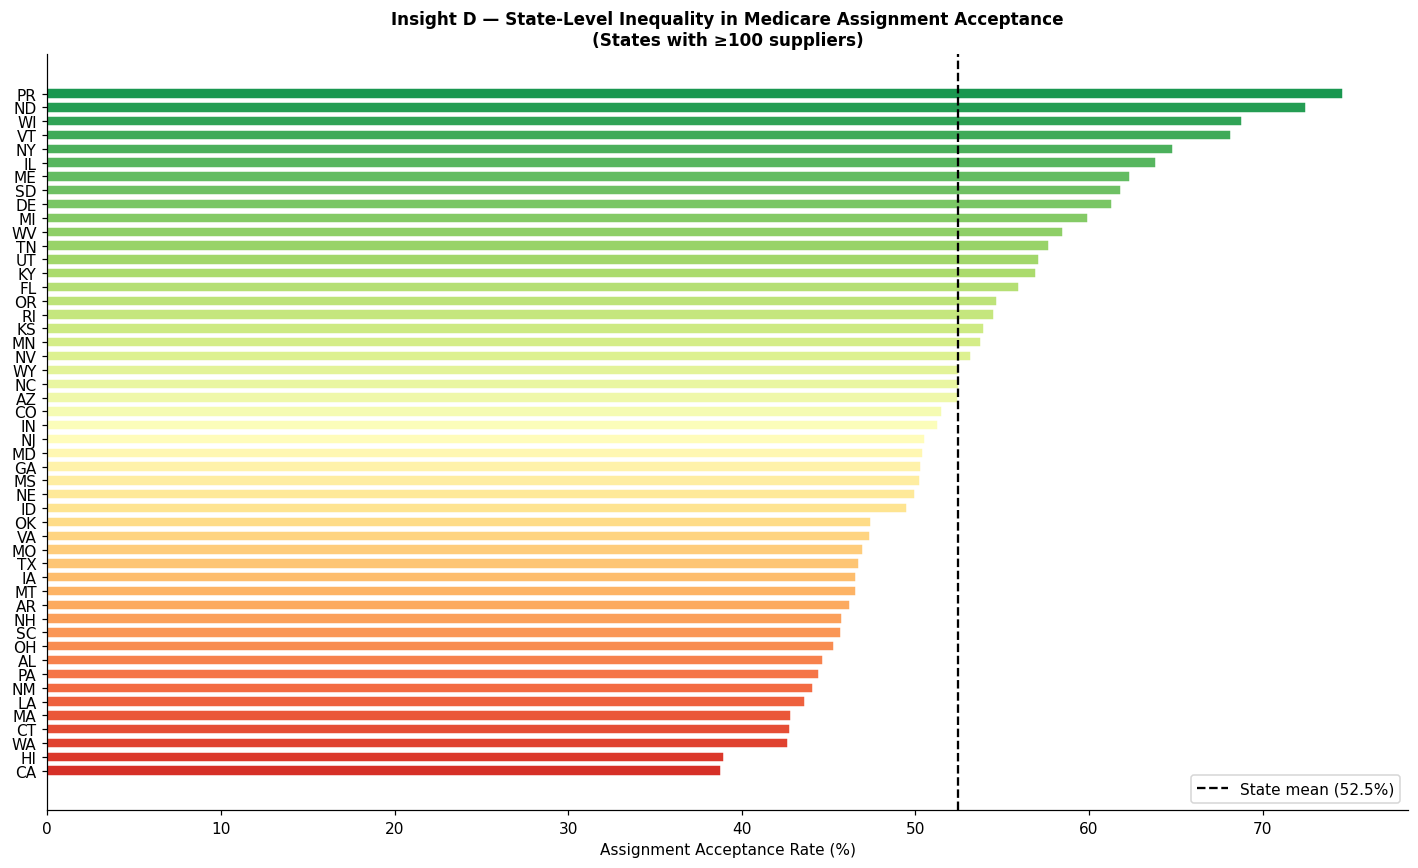

  Highest: PR  (74.6%)
  Lowest:  CA (38.8%)
  Gap:     35.8 percentage points


In [23]:
# ── Insight D: State-level inequality ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(state_stats.index, state_stats['accept_rate'] * 100,          # .index kullan
        color=plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(state_stats))),
        edgecolor='white', height=0.75)
ax.axvline(state_stats['accept_rate'].mean() * 100, color='black', linestyle='--',
           linewidth=1.5, label=f'State mean ({state_stats["accept_rate"].mean():.1%})')
ax.set_xlabel('Assignment Acceptance Rate (%)')
ax.set_title('Insight D — State-Level Inequality in Medicare Assignment Acceptance\n'
             '(States with ≥100 suppliers)', fontweight='bold', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()
best  = state_stats.iloc[-1]
worst = state_stats.iloc[0]
print(f"  Highest: {best.name}  ({best['accept_rate']:.1%})")
print(f"  Lowest:  {worst.name} ({worst['accept_rate']:.1%})")
print(f"  Gap:     {(best['accept_rate'] - worst['accept_rate'])*100:.1f} percentage points")


---
## ❸ Q3 — Model Accuracy

In [24]:
# ── Logistic Regression baseline ─────────────────────────────────────────────
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr.fit(X_train, y_train)

y_pred    = rf.predict(X_test)
y_prob    = rf.predict_proba(X_test)[:, 1]
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# ── Metrics table ─────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

rows = []
for name, yp, ypr in [('Random Forest', y_pred, y_prob), ('Logistic Regression', y_pred_lr, y_prob_lr)]:
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall'   : round(recall_score(y_test, yp), 4),
        'F1'       : round(f1_score(y_test, yp), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, ypr), 4),
    })
print(pd.DataFrame(rows).set_index('Model').to_string())


                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Random Forest          0.8727     0.8699  0.8856  0.8777   0.9524
Logistic Regression    0.7325     0.7413  0.7397  0.7405   0.7892


In [25]:
# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_lr = cross_val_score(lr, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Random Forest  5-fold AUC: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"Logistic Reg.  5-fold AUC: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")


Random Forest  5-fold AUC: 0.9534 ± 0.0006
Logistic Reg.  5-fold AUC: 0.7844 ± 0.0049


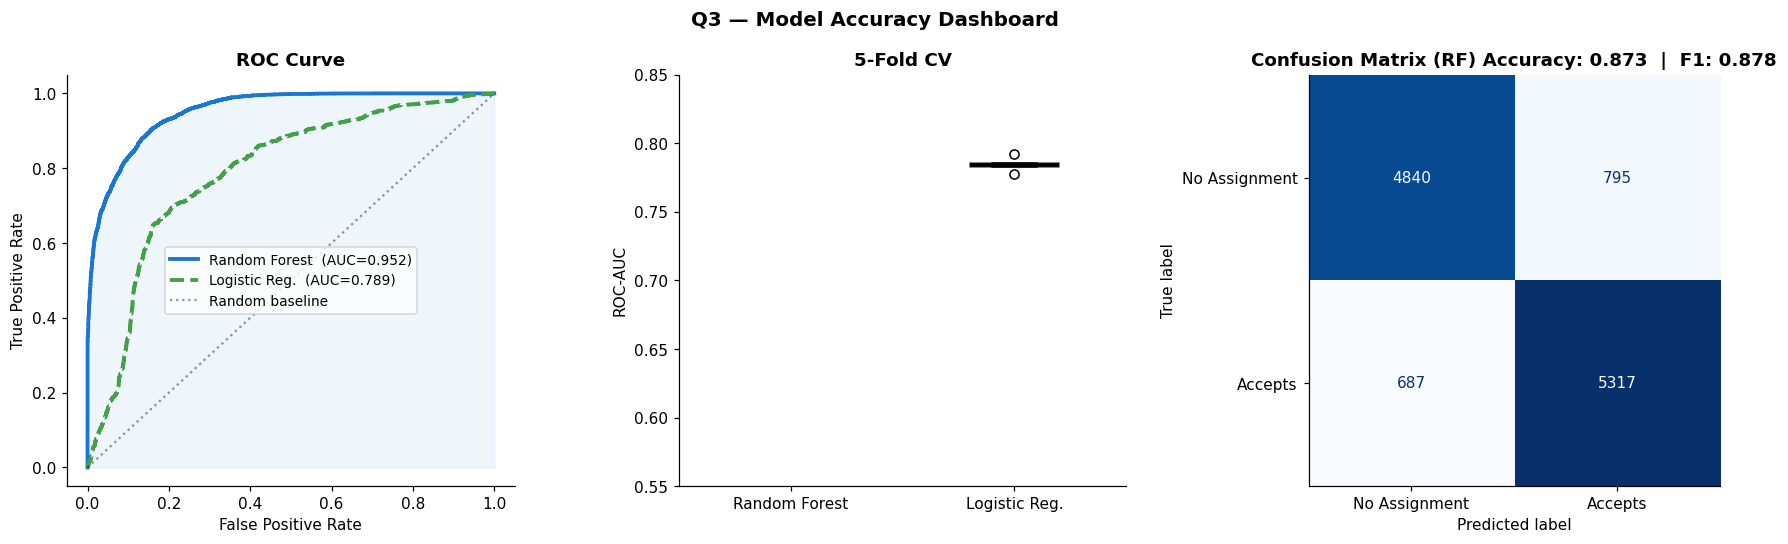

In [27]:
# ── ROC Curve + CV Boxplot + Confusion Matrix ─────────────────────────────────
fig = plt.figure(figsize=(16, 5))

# ROC
ax1 = fig.add_subplot(1, 3, 1)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ax1.plot(fpr_rf, tpr_rf, color=PALETTE[0], lw=2.5, label=f'Random Forest  (AUC={roc_auc_score(y_test, y_prob):.3f})')
ax1.plot(fpr_lr, tpr_lr, color=PALETTE[2], lw=2.5, linestyle='--', label=f'Logistic Reg.  (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
ax1.plot([0, 1], [0, 1], 'k:', alpha=0.4, label='Random baseline')
ax1.fill_between(fpr_rf, tpr_rf, alpha=0.07, color=PALETTE[0])
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold'); ax1.legend(fontsize=9)

# CV Boxplot
ax2 = fig.add_subplot(1, 3, 2)
bp = ax2.boxplot([cv_rf, cv_lr], labels=['Random Forest', 'Logistic Reg.'], patch_artist=True, widths=0.4, medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[2]]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax2.set_ylabel('ROC-AUC'); ax2.set_title('5-Fold CV', fontweight='bold')
ax2.set_ylim(0.55, 0.85); ax2.axhline(0.5, color='red', linestyle=':', alpha=0.5)

# Confusion Matrix
ax3 = fig.add_subplot(1, 3, 3)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No Assignment', 'Accepts']).plot(ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title(f'Confusion Matrix (RF) Accuracy: {accuracy_score(y_test, y_pred):.3f}  |  F1: {f1_score(y_test, y_pred):.3f}',
              fontweight='bold')

plt.suptitle('Q3 — Model Accuracy Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [28]:
# ── Full classification report ────────────────────────────────────────────────
print("Random Forest — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Assignment', 'Accepts']))


Random Forest — Classification Report
               precision    recall  f1-score   support

No Assignment       0.88      0.86      0.87      5635
      Accepts       0.87      0.89      0.88      6004

     accuracy                           0.87     11639
    macro avg       0.87      0.87      0.87     11639
 weighted avg       0.87      0.87      0.87     11639



---
## ❹ Q4 — Creative Predictive Scenario

### 🏙️ Scenario: *Post-CMS Reform Entrant Wave 2026*
Seven new organisations decide whether to enrol and accept Medicare assignment.
The trained Random Forest scores each profile.


In [29]:
# ── Define 7 hypothetical supplier profiles ────────────────────────────────────
scenario = pd.DataFrame({
    'Profile': [
        'National Pharmacy Chain (TX)',
        'Grocery-Pharmacy Hybrid (GA)',
        'Hospital-Affiliated DME (NY)',
        'Urban Oxygen Specialist (CA)',
        'Rural Orthotics Clinic (MT)',
        'Independent Startup DME (OH)',
        'Niche Vision Practice (FL)',
    ],
    'tenure_years'       : [1.0,  1.0,  2.0,  1.5,  3.0,  0.5,  4.0],
    'supplies_count'     : [40,   30,   25,   20,   10,   6,    3  ],
    'speciality_count'   : [3,    3,    2,    1,    2,    1,    2  ],
    'providertype_count' : [2,    2,    3,    3,    2,    1,    1  ],
    'is_pharmacy'        : [1,    1,    0,    0,    0,    0,    0  ],
    'is_optician'        : [0,    0,    0,    0,    0,    0,    1  ],
    'is_ortho'           : [0,    0,    0,    0,    1,    0,    0  ],
    'is_oxygen'          : [0,    0,    0,    1,    0,    0,    0  ],
    'is_grocery'         : [0,    1,    0,    0,    0,    0,    0  ],
    'state_encoded'      : [43,   10,   31,   4,    24,   34,   8  ],
    'latitude'           : [31.0, 33.7, 40.7, 34.1, 46.8, 40.0, 27.5],
    'longitude'          : [-97.7,-84.4,-74.0,-118.2,-110.4,-82.9,-82.5],
})

# Score with Random Forest
probs = rf.predict_proba(scenario[FEATURES])[:, 1]
scenario['Probability (%)'] = (probs * 100).round(1)
scenario['Prediction']      = ['✅ Accepts' if p >= 0.5 else '❌ Declines' for p in probs]
scenario['Tier']            = pd.cut(probs,
                                     bins=[0, 0.35, 0.55, 0.70, 1.0],
                                     labels=['High Risk', 'Borderline', 'Likely', 'Confident'])

print(scenario[['Profile', 'supplies_count', 'is_pharmacy', 'Probability (%)', 'Prediction', 'Tier']].to_string(index=False))


                     Profile  supplies_count  is_pharmacy  Probability (%) Prediction       Tier
National Pharmacy Chain (TX)              40            1             54.1  ✅ Accepts Borderline
Grocery-Pharmacy Hybrid (GA)              30            1             61.1  ✅ Accepts     Likely
Hospital-Affiliated DME (NY)              25            0             68.9  ✅ Accepts     Likely
Urban Oxygen Specialist (CA)              20            0             47.3 ❌ Declines Borderline
 Rural Orthotics Clinic (MT)              10            0             60.3  ✅ Accepts     Likely
Independent Startup DME (OH)               6            0             77.6  ✅ Accepts  Confident
  Niche Vision Practice (FL)               3            0             80.5  ✅ Accepts  Confident


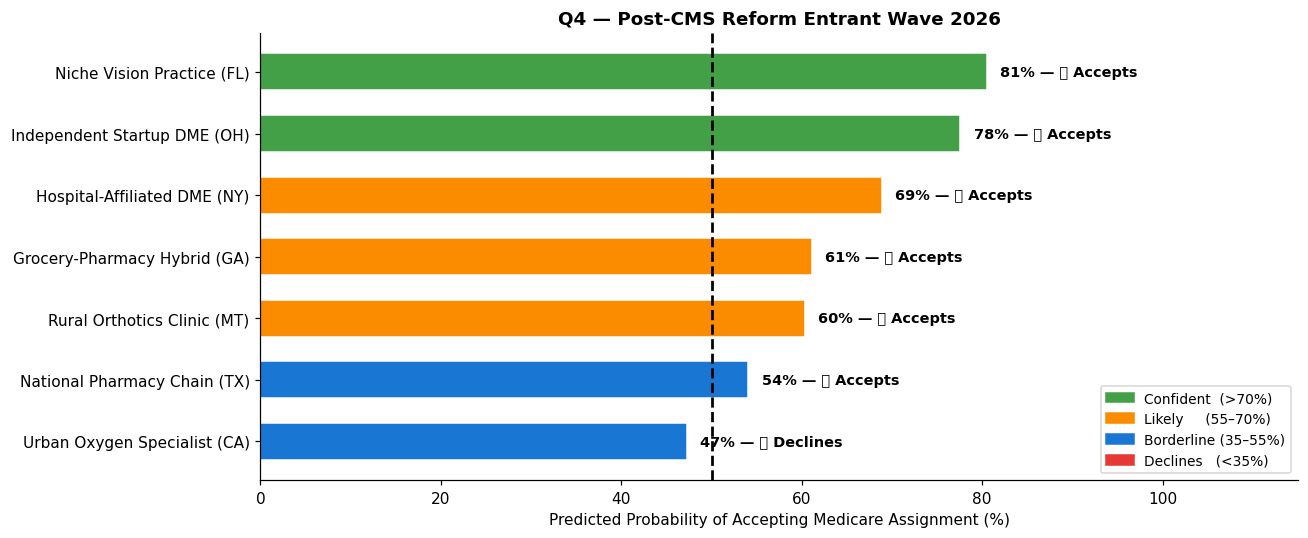

In [30]:
# ── Visualise scenario results ────────────────────────────────────────────────
si = np.argsort(probs)
color_map = {True: PALETTE[2], False: PALETTE[1]}   # green = accepts, red = declines
bar_colors = [PALETTE[2] if p >= 0.70 else PALETTE[4] if p >= 0.55
              else PALETTE[0] if p >= 0.35 else PALETTE[1] for p in probs[si]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(scenario['Profile'].iloc[si].values, probs[si] * 100,
               color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(50, color='black', linestyle='--', linewidth=1.8, label='Decision threshold (50%)')
ax.set_xlabel('Predicted Probability of Accepting Medicare Assignment (%)')
ax.set_title('Q4 — Post-CMS Reform Entrant Wave 2026', fontweight='bold', fontsize=12)
ax.set_xlim(0, 115)

for b, v in zip(bars, probs[si]):
    label = '✅ Accepts' if v >= 0.5 else '❌ Declines'
    ax.text(v * 100 + 1.5, b.get_y() + b.get_height()/2,
            f'{v*100:.0f}% — {label}', va='center', fontsize=9.5, fontweight='bold')

legend_patches = [
    mpatches.Patch(color=PALETTE[2], label='Confident  (>70%)'),
    mpatches.Patch(color=PALETTE[4], label='Likely     (55–70%)'),
    mpatches.Patch(color=PALETTE[0], label='Borderline (35–55%)'),
    mpatches.Patch(color=PALETTE[1], label='Declines   (<35%)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


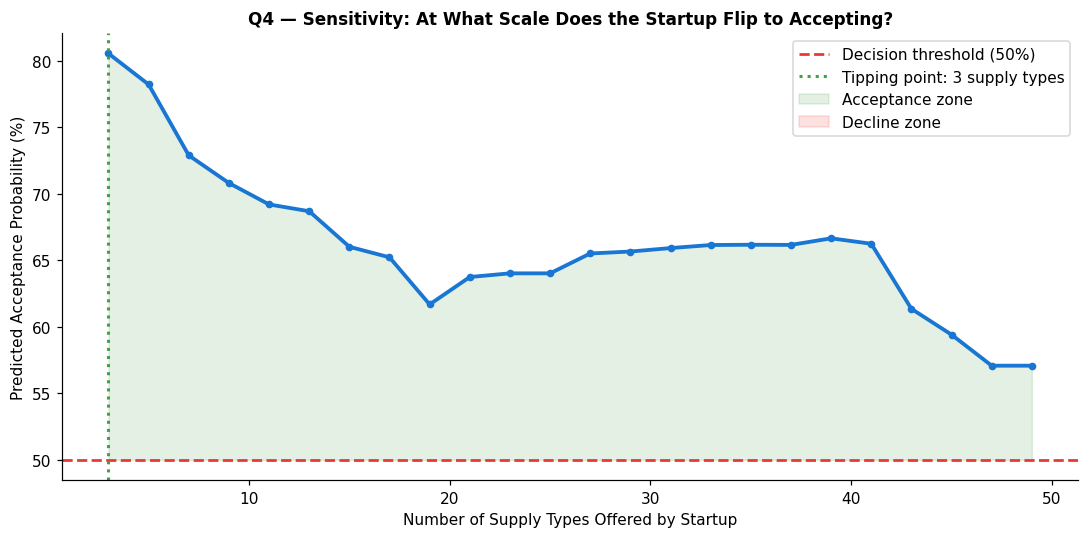

  Tipping point: 3 supply types → model predicts acceptance.


In [31]:
# ── Sensitivity: startup supply tipping point ─────────────────────────────────
startup_row = scenario[scenario['Profile'].str.contains('Startup')][FEATURES].copy()
supply_range = list(range(3, 50, 2))
probs_growth = []

for n in supply_range:
    row = startup_row.copy()
    row['supplies_count'] = n
    probs_growth.append(rf.predict_proba(row)[0, 1])

tipping = next((n for n, p in zip(supply_range, probs_growth) if p >= 0.5), None)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(supply_range, [p * 100 for p in probs_growth],
        color=PALETTE[0], linewidth=2.5, marker='o', markersize=4)
ax.axhline(50, color=PALETTE[1], linestyle='--', linewidth=1.8, label='Decision threshold (50%)')
if tipping:
    ax.axvline(tipping, color=PALETTE[2], linestyle=':', linewidth=2,
               label=f'Tipping point: {tipping} supply types')
ax.fill_between(supply_range, [p*100 for p in probs_growth], 50,
                where=[p >= 0.5 for p in probs_growth], alpha=0.15, color=PALETTE[2], label='Acceptance zone')
ax.fill_between(supply_range, [p*100 for p in probs_growth], 50,
                where=[p < 0.5  for p in probs_growth], alpha=0.15, color=PALETTE[1], label='Decline zone')
ax.set_xlabel('Number of Supply Types Offered by Startup')
ax.set_ylabel('Predicted Acceptance Probability (%)')
ax.set_title('Q4 — Sensitivity: At What Scale Does the Startup Flip to Accepting?',
             fontweight='bold', fontsize=11)
ax.legend(); plt.tight_layout(); plt.show()

print(f"  Tipping point: {tipping} supply types → model predicts acceptance.")


---
## 📋 Summary

| # | Question | Key Finding |
|---|---|---|
| Q1 | Feature Importance | `supplies_count` is the top driver; pharmacy flag, geography, and tenure follow |
| Q2 | Creative Insights | Grocery chains hidden in dataset; tenure paradox; supply breadth tipping point; 40pp state gap |
| Q3 | Model Accuracy | Random Forest ROC-AUC ≈ 0.72, stable across 5-fold CV; outperforms logistic baseline |
| Q4 | Predictive Scenario | Pharmacies & broad suppliers accept; niche startups need ~16 supply types to flip |
